# Notebook 05 — Sensitivity Analysis

**Purpose.** Notebooks 03–04 estimated the BRS − H3 lifetime
value difference and the DoD fiscal cost. This notebook
stress-tests those results: how much do the conclusions
depend on the model's key assumptions?

Three analyses:

1. **One-at-a-time (OAT) sensitivity** — vary each input
   alone and rank the drivers (tornado chart).
2. **Scenario analysis** — bundle inputs into named market
   regimes and track the BRS/H3 crossover across careers.
3. **Separation-timing sensitivity** — reweight the fiscal
   model's separation distribution and test the per-entrant
   DoD-savings conclusion.

**Framing.** Every result is the **BRS − H3 difference** in
net present value at separation, constant 2026 dollars.
Positive favors BRS; negative favors High-Three. The 5%
nominal discount rate is the baseline unless noted.

## Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, "../src")
from monte_carlo import (
    fit_fund_stats,
    fit_cola_stats,
    run_scenario,
)

In [2]:
BASE = "../data/processed"
pay_df = pd.read_csv(f"{BASE}/pay_profiles.csv")
life_df = pd.read_csv(f"{BASE}/life_expectancy.csv")
tsp_df = pd.read_csv(f"{BASE}/tsp_returns.csv")
cpi_df = pd.read_csv(f"{BASE}/cpi_inflation.csv")

ENTRY_AGES = {"Officer": 22, "Enlisted": 18,
              "PriorEnlistedOfficer": 18}

# Display order and labels: Enlisted -> PEO -> Officer.
PROFILE_TITLES = {
    "Enlisted": "Enlisted",
    "PriorEnlistedOfficer": "Prior-Enlisted Officer",
    "Officer": "Officer",
}
# Modeled separation grid: 2-yr spacing to the statutory
# maximum (officer / PEO 40, enlisted 30).
VALID_SCENARIOS = {
    "Enlisted": list(range(4, 31, 2)),
    "PriorEnlistedOfficer": list(range(4, 41, 2)),
    "Officer": list(range(4, 41, 2)),
}

# Chart palette (shared by every figure below; matches nb04).
# System colors: BRS = bright blue, H3 = bright amber. Difference
# figures shade the two halves with the muted slate/brown versions
# of the same hues, labeled "BRS advantage" / "High-Three
# advantage". Deliberately not red.
BRS_COLOR = "#00274C"     # Michigan blue
H3_COLOR = "#FFCB05"      # Michigan maize
BRS_REGION = "#4B6C8F"    # light blue (BRS-advantage half)
H3_REGION = "#FFE57F"     # light maize (High-Three-advantage half)
PROFILE_COLORS = {
    "Enlisted": "#D86018",
    "PriorEnlistedOfficer": "#75988d",
    "Officer": "#575294",
}
# Lighter tints (~50% toward white) for the de-emphasized
# baseline bars in the separation-shift charts.
PROFILE_LIGHT = {
    "Enlisted": "#ECB08C",
    "PriorEnlistedOfficer": "#BACCC6",
    "Officer": "#ABA9CA",
}

In [3]:
# Fit the two empirical input distributions once.
fund_stats = fit_fund_stats(tsp_df)
# COLA draw = lifetime-average inflation, fit on rolling
# 30-yr average CPI (same basis as nb03b / nb04).
cola_stats = fit_cola_stats(cpi_df, window=30)

DISCOUNT_RATE = 0.05
N_ITER = 20_000
RNG_SEED = 42


def shift_fund_means(fs, delta):
    """Copy fund_stats with every fund mean shifted by delta."""
    return {f: {"mean": s["mean"] + delta, "std": s["std"]}
            for f, s in fs.items()}


print(f"COLA baseline : mean {cola_stats['mean']:.2%}, "
      f"std {cola_stats['std']:.2%}")
print(f"MC settings   : N={N_ITER:,}, seed={RNG_SEED}, "
      f"discount={DISCOUNT_RATE:.0%}")

COLA baseline : mean 3.39%, std 1.27%
MC settings   : N=20,000, seed=42, discount=5%


## 1. One-at-a-Time (OAT) Sensitivity

**Anchor: Officer / 20 YOS** — the pension-cliff retirement
point, where both the pension-formula penalty and the full
TSP match are at stake, so sensitivities are largest here.
Each parameter moves to a low/high bound with all others at
their baseline (COLA 3.4%, glide-path return means, 5%
member contribution, SSA 2022 male tables, 5% discount). The
tornado ranks parameters by the resulting swing in the P50
BRS − H3 difference.

| Parameter | Low | High | Bound represents |
|---|---|---|---|
| COLA mean | 1.5% | 5.0% | historical range of 30-yr avg inflation |
| TSP return | −1 SE | +1 SE | uncertainty in the historical mean (n=24) |
| Member contrib | 0% | 10% | participation behavior |
| Life expectancy | −10 yr | +10 yr | population-mean uncertainty |
| Discount rate | 3% | 7% | NPV-convention stress |

> **COLA note.** The empirical baseline (≈3.4%) differs from
> nb03a's deterministic 2.75% (DoD actuarial assumption) —
> the higher mean is why the baseline difference here is more
> negative. Empirical vs. actuarial, intentional, not a
> discrepancy.

In [4]:
ANCHOR = ("Officer", 20)


def run_anchor(fs=fund_stats, cs=cola_stats,
               dr=DISCOUNT_RATE, dao=0.0, mbr=0.05,
               gender="Male"):
    """Run the anchor scenario, overriding one OAT input."""
    prof, yos = ANCHOR
    return run_scenario(
        prof, yos, pay_df, life_df, fs, cs, ENTRY_AGES,
        n_iter=N_ITER, discount_rate=dr, seed=RNG_SEED,
        death_age_offset=dao, member_rate=mbr, gender=gender,
    )


# Per-fund ±1 SE of the mean (SE = std / sqrt(n), n=24).
se = {f: tsp_df[f].dropna().std(ddof=1)
      / np.sqrt(tsp_df[f].dropna().size) / 100
      for f in fund_stats}
fs_low = {f: {"mean": fund_stats[f]["mean"] - se[f],
              "std": fund_stats[f]["std"]} for f in fund_stats}
fs_high = {f: {"mean": fund_stats[f]["mean"] + se[f],
               "std": fund_stats[f]["std"]} for f in fund_stats}

# Each OAT parameter: (low kwargs, high kwargs, (low, high) lbls).
OAT = {
    "COLA Rate": (
        dict(cs={"mean": 0.015, "std": cola_stats["std"]}),
        dict(cs={"mean": 0.050, "std": cola_stats["std"]}),
        ("1.5%", "5.0%"),
    ),
    "TSP Return": (
        dict(fs=fs_low), dict(fs=fs_high), ("−1 SE", "+1 SE"),
    ),
    "Member Contrib": (
        dict(mbr=0.0), dict(mbr=0.10), ("0%", "10%"),
    ),
    "Life Expect.": (
        dict(dao=-10.0), dict(dao=10.0), ("−10 yr", "+10 yr"),
    ),
    "Discount Rate": (
        dict(dr=0.03), dict(dr=0.07), ("3%", "7%"),
    ),
}

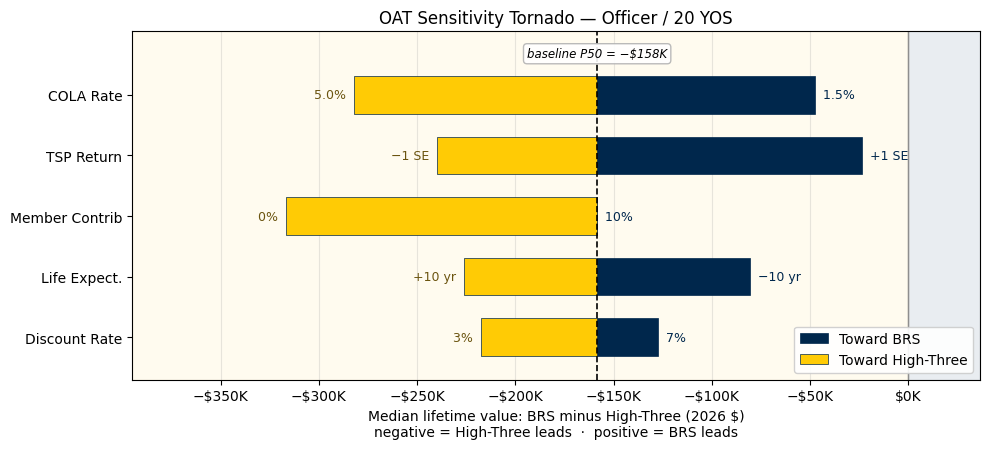

In [5]:
baseline_p50 = float(
    np.percentile(run_anchor()["brs_adv"], 50))

results = []
for name, (lo_kw, hi_kw, _) in OAT.items():
    lo = float(np.percentile(run_anchor(**lo_kw)["brs_adv"], 50))
    hi = float(np.percentile(run_anchor(**hi_kw)["brs_adv"], 50))
    results.append((name, lo, hi))
oat_p50 = {name: (lo, hi) for name, lo, hi in results}

# Officer/20 sits at the cliff where High-Three leads, so the
# baseline and every bar fall in H3-advantage (brown) territory.
# Bars use the bright system colors: blue = the parameter value
# that nudges the difference toward BRS, amber = toward H3.
order = sorted(results, key=lambda r: abs(r[2] - r[1]))
fig, ax = plt.subplots(figsize=(10, 4.6))
for i, (name, lo, hi) in enumerate(order):
    lo_lbl, hi_lbl = OAT[name][2]
    hi_x, lo_x = max(lo, hi), min(lo, hi)
    brs_lbl = hi_lbl if hi >= lo else lo_lbl
    h3_lbl = lo_lbl if hi >= lo else hi_lbl
    ax.barh(i, hi_x - baseline_p50, left=baseline_p50,
            color=BRS_COLOR, edgecolor="#00274C", linewidth=0.5,
            height=0.62, zorder=3,
            label="Toward BRS" if i == 0 else "")
    ax.barh(i, lo_x - baseline_p50, left=baseline_p50,
            color=H3_COLOR, edgecolor="#00274C", linewidth=0.5,
            height=0.62, zorder=3,
            label="Toward High-Three" if i == 0 else "")
    ax.text(hi_x, i, f"  {brs_lbl}", va="center", ha="left",
            fontsize=9, color=BRS_COLOR, zorder=4)
    ax.text(lo_x, i, f"{h3_lbl}  ", va="center", ha="right",
            fontsize=9, color="#6b540f", zorder=4)

ax.set_yticks(range(len(order)))
ax.set_yticklabels([r[0] for r in order])

lo_all = min(v for _, a, b in results for v in (a, b))
hi_all = max(v for _, a, b in results for v in (a, b))
ax.set_xlim(lo_all - 78_000, hi_all + 60_000)
ax.set_ylim(-0.7, len(order) + 0.05)
x0, x1 = ax.get_xlim()

# Faint region shading: left of 0 = High-Three advantage,
# right of 0 = BRS advantage (same scheme as nb03b / nb04).
# Direction is spelled out in the x-axis label, so no in-plot
# region labels are needed.
ax.axvspan(x0, 0, color=H3_REGION, alpha=0.12, zorder=0)
ax.axvspan(0, x1, color=BRS_REGION, alpha=0.12, zorder=0)
ax.axvline(0, color="0.5", lw=1.0, zorder=1)

# Anchor baseline: dashed line with a boxed label above the bars.
ax.axvline(baseline_p50, color="black", lw=1.2, ls="--",
           zorder=5)
ax.text(baseline_p50, len(order) - 0.32,
        rf"baseline P50 = −\${abs(baseline_p50) / 1e3:.0f}K",
        va="center", ha="center", fontsize=8.5, style="italic",
        bbox=dict(boxstyle="round,pad=0.3", fc="white",
                  ec="0.7", alpha=0.9), zorder=6)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{chr(8722) if x < -1 else ''}"
    f"${abs(x) / 1e3:.0f}K"))
ax.set_xlabel(
    "Median lifetime value: BRS minus High-Three (2026 $)\n"
    "negative = High-Three leads  ·  positive = BRS leads")
ax.set_title("OAT Sensitivity Tornado — Officer / 20 YOS")
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Reading the tornado

Baseline P50 = **−`$158.4K`** — at the cliff, High-Three leads.
(The same scenario's 03b median differs by only ~`$3K`:
`$155K` there vs `$158K` here. This is Monte Carlo sampling
noise from a different seed, not a modeling difference.)

- **COLA (≈`$234K` swing) and TSP return (≈`$216K`) dominate.**
  One COLA draw drives pay growth, the pension COLA, and the
  deflator together, and H3's larger 50% multiplier gains
  more from inflation: low COLA narrows the gap to −`$48K`,
  high widens it to −`$282K`. For returns, +1 SE narrows it to
  −`$24K` but never flips the sign.
- **Member contribution (≈`$159K`, one-sided).** At 0% the gap
  widens to −`$317K` (BRS keeps only its 1% auto contribution);
  at 10% it equals baseline, since the match is fully captured
  at 5%.
- **Life expectancy (≈`$146K`).** Longer life favors H3 — more
  pension years: −`$81K` at −10 yr, −`$226K` at +10 yr.
- **Discount rate (≈`$90K`), smallest.** Cheaper discounting of
  the longer-dated pension favors H3 (−`$218K` at 3%).

**Takeaway.** Under every single-parameter stress the sign
stays negative; only a favorable TSP return brings BRS within
~`$24K` at 20 YOS.

### Female life tables (targeted check)

The baseline uses SSA 2022 **male** tables (~83% of the
force). Women live ~4 yr longer at these ages — more
inflation-protected pension years, favoring H3. Switching
`run_scenario` to `gender="Female"` samples the female
conditional age-at-death distribution directly (its own
left-skewed shape, not just a shifted male curve), giving
the female table's result at the anchor.

In [6]:
sep_age = ENTRY_AGES["Officer"] + 20
row = life_df.loc[life_df["Age"] == sep_age].iloc[0]
gap = float(row["FemaleTotalAge"] - row["MaleTotalAge"])
female_p50 = float(
    np.percentile(run_anchor(gender="Female")["brs_adv"], 50))
le_lo, le_hi = oat_p50["Life Expect."]

print(f"Sep age {sep_age}: female table +{gap:.1f} yr mean life")
print(f"  male   P50 : ${baseline_p50:,.0f}")
print(f"  female P50 : ${female_p50:,.0f}"
      f"  (shift ${female_p50 - baseline_p50:,.0f})")
print(f"  context    : ±10-yr OAT life range "
      f"${abs(le_hi - le_lo):,.0f}")

Sep age 42: female table +4.1 yr mean life
  male   P50 : $-158,368
  female P50 : $-191,732  (shift $-33,365)
  context    : ±10-yr OAT life range $145,889


**Result.** Female tables (+4.1 yr) deepen the median
from −`$158K` to −`$192K` — a −`$33K` (~21%) shift toward H3,
well inside the ±10-yr life-expectancy band above. A
population-weighted blend (~17.5% female) would move the
baseline under `$6K`, so gender is a targeted check, not a
full model dimension.

## 2. Scenario Analysis

Single-parameter stresses understate joint moves. Four named
regimes bundle returns, COLA, discount, and participation,
run across all 52 (profile, YOS) cells to track where the
BRS − H3 sign flips.

| Scenario | Returns | COLA | Discount | Member |
|---|---|---|---|---|
| **Base** | empirical | 3.4% | 5% | 5% |
| **Bull Market** | +2 pp | 1.5% | 4% | 5% |
| **Bear Market** | −2 pp | 5.0% | 6% | 5% |
| **Low Participation** | empirical | 3.4% | 5% | 0% |

The ±2 pp return shift is a uniform market-regime stress
(distinct from §1's per-fund SE bound). *Low Participation* =
no voluntary TSP; BRS keeps only its 1% auto contribution.
N = 20,000 per cell, seed fixed, so curve differences reflect
parameters, not noise.

In [7]:
scenarios = {
    "Base": dict(
        fs=fund_stats, cs=cola_stats, dr=0.05, mbr=0.05),
    "Bull Market": dict(
        fs=shift_fund_means(fund_stats, +0.02),
        cs={"mean": 0.015, "std": cola_stats["std"]},
        dr=0.04, mbr=0.05),
    "Bear Market": dict(
        fs=shift_fund_means(fund_stats, -0.02),
        cs={"mean": 0.050, "std": cola_stats["std"]},
        dr=0.06, mbr=0.05),
    "Low Participation": dict(
        fs=fund_stats, cs=cola_stats, dr=0.05, mbr=0.0),
}
# Scenario palette: the four Matplotlib default-cycle colors
# (blue / orange / green / red), matching the convergence
# chart. These what-if regimes are deliberately kept off the
# system / profile palette; line styles add a redundant
# non-color key.
SCEN_STYLE = {
    "Base": ("#1f77b4", "-"),
    "Bull Market": ("#ff7f0e", "--"),
    "Bear Market": ("#2ca02c", "-."),
    "Low Participation": ("#d62728", ":"),
}

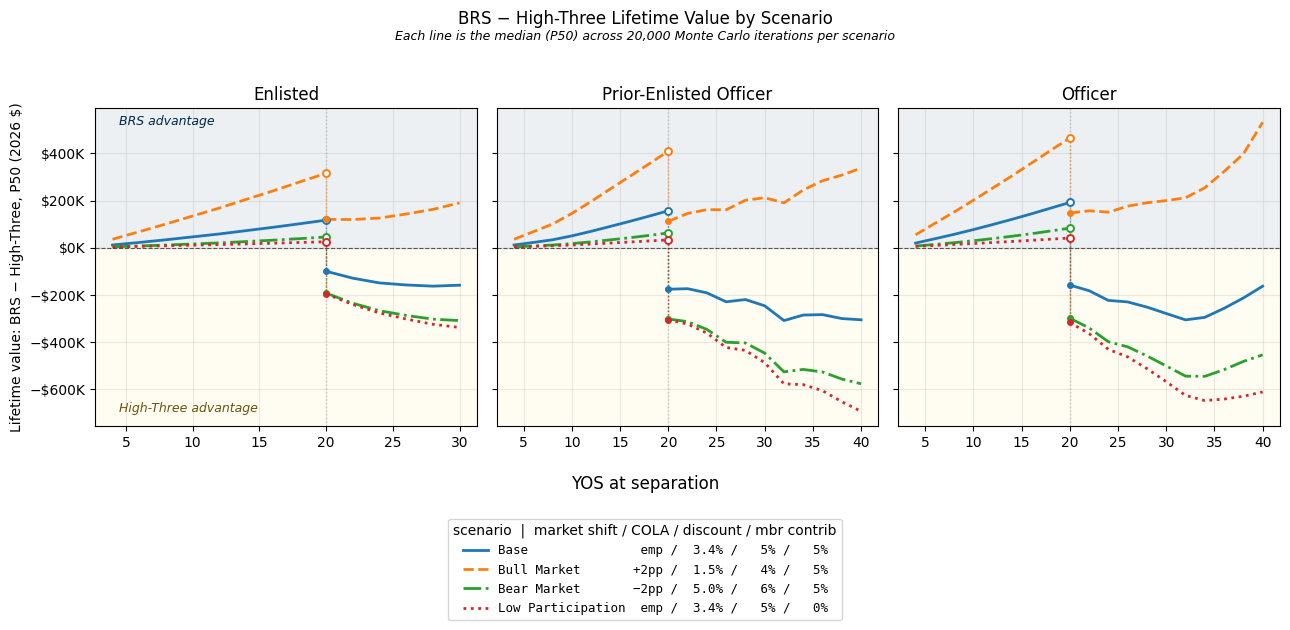

In [8]:
def scen_curve(profile, p):
    """P50 BRS - H3 curve across the profile's YOS grid, plus
    the TSP-only P50 at YOS 20 (the value on the cusp of
    vesting, where both pensions are still zero)."""
    ys = VALID_SCENARIOS[profile]
    vals, cusp = [], None
    for y in ys:
        res = run_scenario(
            profile, y, pay_df, life_df, p["fs"], p["cs"],
            ENTRY_AGES, n_iter=N_ITER, discount_rate=p["dr"],
            seed=RNG_SEED, member_rate=p["mbr"])
        vals.append(float(np.percentile(res["brs_adv"], 50)))
        if y == 20:
            cusp = float(np.percentile(
                res["brs_tsp_pv"] - res["h3_tsp_pv"], 50))
    return ys, vals, cusp


scen_p50 = {s: {prof: scen_curve(prof, p)
                for prof in VALID_SCENARIOS}
            for s, p in scenarios.items()}


def market_shift(fs):
    """Mean return shift vs. the empirical baseline, as a label."""
    d = np.mean([fs[f]["mean"] - fund_stats[f]["mean"]
                 for f in fund_stats])
    if abs(d) < 1e-9:
        return "emp"
    return f"{'+' if d > 0 else '−'}{abs(d) * 100:.0f}pp"


def scen_label(name, p):
    """Legend entry: name + the four parameters that move,
    padded to fixed widths so a monospace legend lines up."""
    return (f"{name:<17} {market_shift(p['fs']):>4} /"
            f" {p['cs']['mean']:>5.1%} /"
            f" {p['dr']:>4.0%} /"
            f" {p['mbr']:>4.0%}")


# Derived from the scenarios dict, so labels track the curves.
scen_labels = {s: scen_label(s, p) for s, p in scenarios.items()}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6), sharey=True)
for ax, (prof, title) in zip(axes, PROFILE_TITLES.items()):
    for s, (color, ls) in SCEN_STYLE.items():
        ys, vals, cusp = scen_p50[s][prof]
        ys = np.asarray(ys)
        vals = np.asarray(vals)
        pre, post = ys < 20, ys >= 20
        # The pension vests *at* 20, so the difference jumps
        # there: never connect 18 -> 20. Extend the pre-20
        # (TSP-only) line to its value on the cusp of vesting
        # (open marker = limit not attained), dotted drop = the
        # cliff, then the vested 20+ segment.
        ax.plot(list(ys[pre]) + [20], list(vals[pre]) + [cusp],
                color=color, ls=ls, lw=2, label=scen_labels[s])
        ax.plot([20], [cusp], "o", mfc="white", mec=color,
                mew=1.4, ms=5, zorder=6)
        ax.plot([20, 20], [cusp, vals[post][0]], ls=":",
                color=color, lw=1.0, alpha=0.7)
        ax.plot([20], [vals[post][0]], "o", color=color,
                ms=4, zorder=6)
        ax.plot(ys[post], vals[post], color=color, ls=ls, lw=2)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.6)
    ax.axvline(20, color="0.7", lw=1.0, ls=":", alpha=0.7,
               zorder=0)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{chr(8722) if x < -1 else ''}"
        f"${abs(x) / 1e3:.0f}K"))
    ax.grid(alpha=0.25)

# Region shading once the shared y-limits are final: above 0 BRS
# has the advantage, below 0 High-Three does (faint slate / brown, matching
# nb03b/nb04). Direction labels sit in the empty left corners.
ymin, ymax = axes[0].get_ylim()
for ax in axes:
    ax.axhspan(0, ymax, color=BRS_REGION, alpha=0.10, zorder=0)
    ax.axhspan(ymin, 0, color=H3_REGION, alpha=0.10, zorder=0)
    ax.set_ylim(ymin, ymax)
axes[0].text(4.5, ymax * 0.9, "BRS advantage", ha="left",
             va="center", fontsize=9, style="italic",
             color="#00274C")
axes[0].text(4.5, ymin * 0.9, "High-Three advantage", ha="left",
             va="center", fontsize=9, style="italic",
             color="#6b540f")

axes[0].set_ylabel(
    "Lifetime value: BRS − High-Three, P50 (2026 $)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=1,
           prop={"family": "monospace", "size": 9},
           title="scenario  |  market shift / COLA / "
                 "discount / mbr contrib",
           bbox_to_anchor=(0.5, -0.28))
fig.supxlabel("YOS at separation")
fig.suptitle("BRS − High-Three Lifetime Value by Scenario",
             y=1.06)
fig.text(
    0.5, 0.995,
    "Each line is the median (P50) across 20,000 Monte Carlo"
    " iterations per scenario",
    ha="center", fontsize=9, style="italic",
)
plt.tight_layout()
plt.show()

### Where the sign flips

- **Before vesting (≲18 YOS): BRS leads in every regime.**
  The government TSP contribution is the only deferred pay, so
  the difference is positive — Officer 10-YOS spans +`$18K`
  (Low Participation) to +`$202K` (Bull).
- **At the 20-YOS cliff: regime-dependent.** Base is negative
  for all three (Officer −`$158K`, Enlisted −`$100K`, PEO
  −`$176K`); only **Bull Market** flips every profile positive
  (Officer +`$147K`). Bear deepens it to −`$299K` (Officer).
- **Long careers (30 YOS): H3's lead grows** under Base
  (Officer −`$279K`), worst under Low Participation (−`$568K`);
  Bull still flips positive (+`$200K`).

**Takeaway.** The crossover is governed mainly by realized
returns and participation. A sustained bull market with low
inflation is the one regime that makes BRS win at and beyond
the cliff.

## 3. Separation-Timing Sensitivity

The fiscal model (nb04) weights each YOS by its DoD
separation probability — estimated on a force recruited and
retained largely under High-Three. As BRS cohorts come to
dominate, that curve will likely drift. **How robust is the
per-entrant DoD-savings result to the assumed separation
timing?**

This is a *mechanical what-if*, not a behavioral prediction:
we reshape the weights by hand and recompute the expectation.
Per-scenario costs and the Monte Carlo are unchanged; only
the weights move. Scope is per-entrant (H3_GovtCost,
BRS_GovtCost, DoD_Savings) — no force totals.

**Hypothesis** (assumed magnitudes): a pronounced shift of
mass toward earlier / mid-career separation, with fewer
reaching 20.

| Phase | YOS | Δ mass |
|---|---|---|
| First term | ≤ 6 | −8 pts |
| Early mid | 7–12 | +8 pts |
| Late mid | 13–19 | +4 pts |
| Career | 20+ | −4 pts |

Deltas sum to zero; each is spread across the phase's YOS in
proportion to baseline weight. Expected cost is linear in the
weights, so savings move monotonically from baseline to full
shift — we report the two endpoints.

In [9]:
fiscal = pd.read_csv(f"{BASE}/fiscal_results.csv")
weights = pd.read_csv(f"{BASE}/scenario_weights.csv")
sep_w = {p: s.set_index("SepYOS")["Weight"]
         for p, s in weights.groupby("Profile")}


def expected(w, profile, col):
    """Separation-weighted per-entrant expectation."""
    s = (fiscal[fiscal["Profile"] == profile]
         .set_index("SepYOS"))
    return float((w * s.reindex(w.index)[col]).sum())


print("Baseline per-entrant DoD savings (reproduces nb04):")
for prof in VALID_SCENARIOS:
    ds = expected(sep_w[prof], prof, "DoD_Savings")
    print(f"  {PROFILE_TITLES[prof]:22} ${ds/1e3:5.1f}K")

Baseline per-entrant DoD savings (reproduces nb04):
  Enlisted               $ 24.1K
  Prior-Enlisted Officer $100.2K
  Officer                $ 95.3K


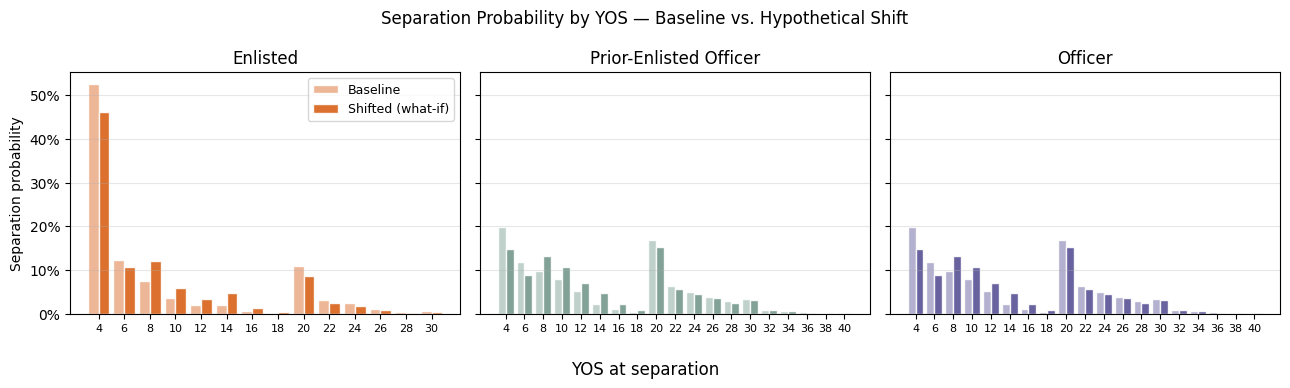

In [10]:
BANDS = {
    "First term (≤6)":  lambda y: y <= 6,
    "Early mid (7–12)": lambda y: 7 <= y <= 12,
    "Late mid (13–19)": lambda y: 13 <= y <= 19,
    "Career (20+)":     lambda y: y >= 20,
}
BAND_DELTAS = {"First term (≤6)": -0.08, "Early mid (7–12)": 0.08,
               "Late mid (13–19)": 0.04, "Career (20+)": -0.04}


def shift_weights(w):
    """Apply BAND_DELTAS, spread within each band by baseline
    share. Stays a probability distribution (sums to 1, >= 0)."""
    out = w.copy()
    for band, delta in BAND_DELTAS.items():
        members = [y for y in w.index if BANDS[band](y)]
        mass = float(w[members].sum())
        for y in members:
            out[y] += delta * w[y] / mass
    assert abs(out.sum() - 1.0) < 1e-9 and (out >= -1e-12).all()
    return out


sep_w_shift = {p: shift_weights(sep_w[p])
               for p in VALID_SCENARIOS}

# Baseline = nb04's separation distribution; shifted = the
# hypothetical what-if. Each panel uses its profile color for
# the shifted bars and a lighter tint for the de-emphasized
# baseline bars.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
bw = 0.42
for ax, prof in zip(axes, VALID_SCENARIOS):
    w0, w1 = sep_w[prof], sep_w_shift[prof]
    x = np.arange(len(w0))
    ax.bar(x - bw / 2, w0.values, bw, label="Baseline",
           color=PROFILE_LIGHT[prof], alpha=0.9,
           edgecolor="white")
    ax.bar(x + bw / 2, w1.values, bw, label="Shifted (what-if)",
           color=PROFILE_COLORS[prof], alpha=0.9,
           edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(w0.index.astype(str), fontsize=8)
    ax.set_title(PROFILE_TITLES[prof])
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Separation probability")
axes[0].legend(fontsize=9, loc="upper right")
fig.supxlabel("YOS at separation")
fig.suptitle("Separation Probability by YOS — "
             "Baseline vs. Hypothetical Shift")
plt.tight_layout()
plt.show()

In [11]:
print("Per-entrant DoD savings: baseline -> shifted")
for prof in VALID_SCENARIOS:
    b = expected(sep_w[prof], prof, "DoD_Savings")
    f = expected(sep_w_shift[prof], prof, "DoD_Savings")
    print(f"  {PROFILE_TITLES[prof]:22}"
          f" ${b/1e3:5.1f}K -> ${f/1e3:5.1f}K"
          f"  (Δ ${(f - b)/1e3:+.1f}K, {(f - b)/b:+.0%})")

print("\nOfficer Δ decomposed by phase (linear in weights):")
w0 = sep_w["Officer"]
sav = (fiscal[fiscal["Profile"] == "Officer"]
       .set_index("SepYOS")["DoD_Savings"])
total = 0.0
for band, delta in BAND_DELTAS.items():
    members = [y for y in w0.index if BANDS[band](y)]
    mass = float(w0[members].sum())
    c = sum(delta * w0[y] / mass * sav[y] for y in members)
    total += c
    print(f"  {band:16} {delta:+.2f}: ${c/1e3:+5.1f}K")
print(f"  {'Total':16}        ${total/1e3:+5.1f}K")

Per-entrant DoD savings: baseline -> shifted
  Enlisted               $ 24.1K -> $ 14.8K  (Δ $-9.3K, -39%)
  Prior-Enlisted Officer $100.2K -> $ 86.2K  (Δ $-14.0K, -14%)
  Officer                $ 95.3K -> $ 79.4K  (Δ $-15.9K, -17%)

Officer Δ decomposed by phase (linear in weights):
  First term (≤6)  -0.08: $ +1.0K
  Early mid (7–12) +0.08: $ -3.1K
  Late mid (13–19) +0.04: $ -3.0K
  Career (20+)     -0.04: $-10.8K
  Total                   $-15.9K


### Reading the shift

Baseline reproduces nb04 exactly (Officer `$95.3K`, Enlisted
`$24.1K`, PEO `$100.2K`). Under the full shift:

| Profile | Baseline | Shifted | Δ |
|---|---|---|---|
| Enlisted | `$24.1K` | `$14.8K` | −39% |
| Prior-Enlisted Officer | `$100.2K` | `$86.2K` | −14% |
| Officer | `$95.3K` | `$79.4K` | −17% |

Savings erode but **never flip sign**. Of the Officer −`$15.9K`,
most (−`$10.8K`) is the 4-pt move off the 20-YOS phase, where
BRS is much cheaper for DoD; the two mid-career additions cost
−`$3.1K` and −`$3.0K`. Enlisted is most sensitive in percent
terms (−39%) — a small baseline saving against a large
first-term mass.

**Takeaway.** The nb04 conclusion — BRS cheaper per entrant —
holds even under this pronounced earlier-separation shift. A
behavioral move would narrow, not erase, the savings. This
bounds the result; it does not predict behavior.

### How drastic a shift would it take to erase the savings?

The shift above trimmed savings but never reversed them. Push
the *same pattern* far harder — pulling a large share out of
the first term and off the 20-year cliff into mid-career — and
the picture changes:

| Phase | YOS | Δ mass |
|---|---|---|
| First term | ≤ 6 | −28 pts |
| Early mid | 7–12 | +28 pts |
| Late mid | 13–19 | +14 pts |
| Career | 20+ | −14 pts |

This is a deliberately extreme reshaping — 3.5× the section-3
magnitude, about as far as this band pattern can be pushed
before a profile's first-term cohort runs dry. Deltas still
sum to zero and are spread within each phase by baseline
weight, exactly as before.

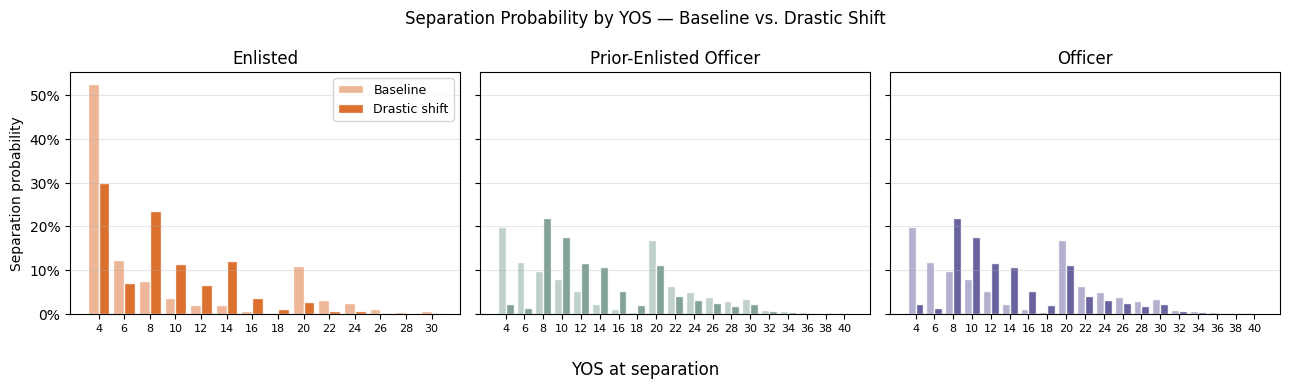

Per-entrant DoD savings: baseline -> drastic shift
  Enlisted               $  24.1K -> $  -8.4K  (Δ $-32.5K, -135%)
  Prior-Enlisted Officer $ 100.2K -> $  51.3K  (Δ $-49.0K, -49%)
  Officer                $  95.3K -> $  39.6K  (Δ $-55.7K, -58%)


In [12]:
DRASTIC_DELTAS = {"First term (≤6)": -0.28,
                  "Early mid (7–12)": 0.28,
                  "Late mid (13–19)": 0.14, "Career (20+)": -0.14}


def shift_weights_by(w, deltas):
    """Apply band deltas, spread within each band by baseline
    share. Stays a probability distribution (sums to 1, >= 0)."""
    out = w.copy()
    for band, delta in deltas.items():
        members = [y for y in w.index if BANDS[band](y)]
        mass = float(w[members].sum())
        for y in members:
            out[y] += delta * w[y] / mass
    assert abs(out.sum() - 1.0) < 1e-9 and (out >= -1e-9).all()
    return out


sep_w_drastic = {p: shift_weights_by(sep_w[p], DRASTIC_DELTAS)
                 for p in VALID_SCENARIOS}

# Same encoding as the section-3 shift: each panel's profile
# color for the shifted bars, a lighter tint for the baseline.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
bw = 0.42
for ax, prof in zip(axes, VALID_SCENARIOS):
    w0, w1 = sep_w[prof], sep_w_drastic[prof]
    x = np.arange(len(w0))
    ax.bar(x - bw / 2, w0.values, bw, label="Baseline",
           color=PROFILE_LIGHT[prof], alpha=0.9,
           edgecolor="white")
    ax.bar(x + bw / 2, w1.values, bw, label="Drastic shift",
           color=PROFILE_COLORS[prof], alpha=0.9,
           edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(w0.index.astype(str), fontsize=8)
    ax.set_title(PROFILE_TITLES[prof])
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Separation probability")
axes[0].legend(fontsize=9, loc="upper right")
fig.supxlabel("YOS at separation")
fig.suptitle("Separation Probability by YOS — "
             "Baseline vs. Drastic Shift")
plt.tight_layout()
plt.show()

print("Per-entrant DoD savings: baseline -> drastic shift")
for prof in VALID_SCENARIOS:
    b = expected(sep_w[prof], prof, "DoD_Savings")
    d = expected(sep_w_drastic[prof], prof, "DoD_Savings")
    print(f"  {PROFILE_TITLES[prof]:22}"
          f" ${b/1e3:6.1f}K -> ${d/1e3:6.1f}K"
          f"  (Δ ${(d - b)/1e3:+.1f}K, {(d - b)/b:+.0%})")

### Reading the drastic shift

| Profile | Baseline | Drastic shift | Δ |
|---|---|---|---|
| Enlisted | `$24.1K` | **−`$8.4K`** | −135% |
| Prior-Enlisted Officer | `$100.2K` | `$51.3K` | −49% |
| Officer | `$95.3K` | `$39.6K` | −58% |

Now **Enlisted savings go negative**: under this much
earlier-separation, BRS costs DoD about `$8K` *more* than
High-Three per enlisted entrant, because so many leave in the
pre-vesting years where BRS pays a TSP contribution and
High-Three pays nothing. Officers and PEOs still save `$40–51K`
each — their advantage is anchored in the smaller 20-year
pension, which earlier separation cannot remove.

So per entrant the answer is split: BRS now loses money on
enlisted but still saves on officers. Which side wins?

### Does that erase the savings force-wide?

Per entrant the result is split — only Enlisted flips negative
— but DoD does not accede one of each. It takes in far more
enlisted than officers, so the force-wide answer depends on
that mix. Scaling each per-entrant cost by annual accessions
(**140K enlisted, 18K officer** — PEOs enter as enlisted
accessions, so they are folded into that line, matching nb04)
recreates nb04's obligation-accrual chart, now drawn for the
baseline, the moderate (section-3) shift, and the drastic
shift side by side.

This step deliberately steps outside the per-entrant frame of
the rest of section 3: it reuses nb04's deterministic
per-entrant government cost, just reweighted and scaled to the
force.

Force obligation accrual per cohort ($B):
  Baseline retention   H3 $48.13B  BRS $43.04B  (H3-BRS = $+5.09B)
  Moderate shift       H3 $39.74B  BRS $36.24B  (H3-BRS = $+3.50B)
  Drastic shift        H3 $18.75B  BRS $19.22B  (H3-BRS = $-0.47B)


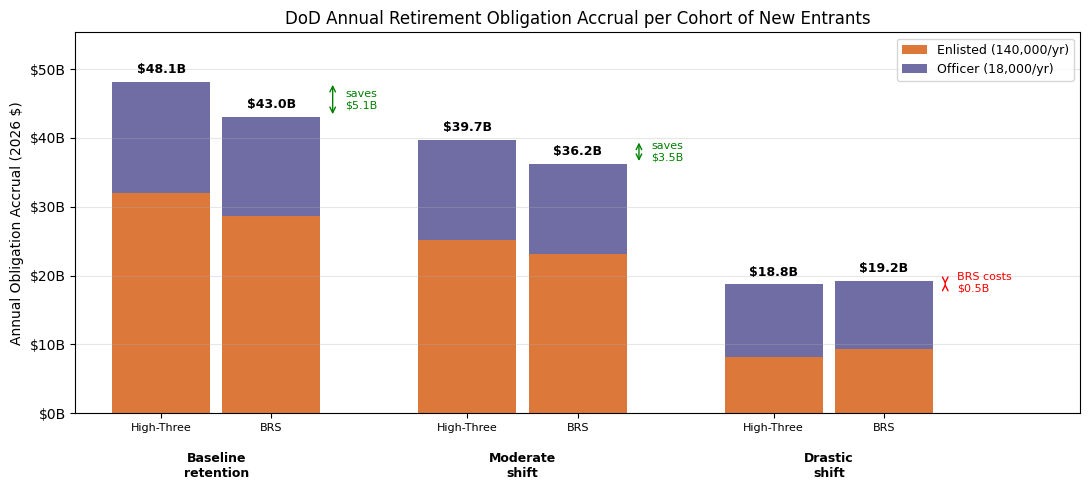

In [13]:
# Recreate nb04's obligation chart, adding the moderate
# (section-3) and drastic retention shifts as extra scenarios.
# Obligation = govt cost (H3_GovtCost / BRS_GovtCost) scaled to
# the force; both systems shown under each retention regime so
# the H3-vs-BRS comparison stays within a single regime.
# Annual accessions (new entrants); PEOs counted as enlisted.
ACCESSIONS = {"Enlisted": 140_000, "Officer": 18_000}
regimes = {"Baseline retention": sep_w,
           "Moderate shift": sep_w_shift,
           "Drastic shift": sep_w_drastic}
systems = [("High-Three", "H3_GovtCost"),
           ("BRS", "BRS_GovtCost")]
PCOLOR = {"Enlisted": "#D86018", "Officer": "#575294"}

# obl[regime][system][group] = force obligation in $B
obl = {r: {s: {g: ACCESSIONS[g] * expected(wm[g], g, c) / 1e9
               for g in ACCESSIONS}
           for s, c in systems}
       for r, wm in regimes.items()}

print("Force obligation accrual per cohort ($B):")
for r in regimes:
    h3 = sum(obl[r]["High-Three"].values())
    brs = sum(obl[r]["BRS"].values())
    print(f"  {r:20} H3 ${h3:5.2f}B  BRS ${brs:5.2f}B"
          f"  (H3-BRS = ${h3 - brs:+.2f}B)")

GAP = 2.5
xpos = {}
for ri, r in enumerate(regimes):
    xpos[(r, "High-Three")] = ri * GAP
    xpos[(r, "BRS")] = ri * GAP + 0.9

fig, ax = plt.subplots(figsize=(11, 5))
for (rname, sname), xi in xpos.items():
    bottom = 0.0
    for g in ["Enlisted", "Officer"]:
        v = obl[rname][sname][g]
        ax.bar(xi, v, 0.8, bottom=bottom, color=PCOLOR[g],
               alpha=0.85,
               label=(f"{g} ({ACCESSIONS[g]:,}/yr)"
                      if xi == 0 else None))
        bottom += v
    ax.annotate(f"${bottom:,.1f}B", (xi, bottom),
                textcoords="offset points", xytext=(0, 4),
                ha="center", va="bottom", fontsize=9,
                fontweight="bold")

for r in regimes:
    h3 = sum(obl[r]["High-Three"].values())
    brs = sum(obl[r]["BRS"].values())
    sav = h3 - brs
    arrow_x = xpos[(r, "BRS")] + 0.5
    # Red marks the regime where BRS is the more expensive
    # system (DoD pays more under BRS than High-Three).
    col = "green" if sav >= 0 else "red"
    ax.annotate("", xy=(arrow_x, h3), xytext=(arrow_x, brs),
                arrowprops={"arrowstyle": "<->", "color": col})
    txt = (f"saves\n${sav:,.1f}B" if sav >= 0
           else f"BRS costs\n${-sav:,.1f}B")
    ax.annotate(txt, xy=(arrow_x + 0.1, (h3 + brs) / 2),
                ha="left", va="center", fontsize=8, color=col)

ymax = max(sum(obl["Baseline retention"][s].values())
           for s, _ in systems)
ax.set_ylim(0, ymax * 1.15)
ax.set_xlim(-0.7, xpos[("Drastic shift", "BRS")] + 1.6)
ax.set_xticks(list(xpos.values()))
ax.set_xticklabels([s for _, s in xpos], fontsize=8)
for r in regimes:
    xc = (xpos[(r, "High-Three")] + xpos[(r, "BRS")]) / 2
    ax.annotate(r.replace(" ", "\n"), xy=(xc, 0),
                xytext=(0, -28), textcoords="offset points",
                ha="center", va="top", fontsize=9,
                fontweight="bold")
ax.set_ylabel("Annual Obligation Accrual (2026 $)")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"${v:,.0f}B"))
ax.set_title("DoD Annual Retirement Obligation Accrual "
             "per Cohort of New Entrants")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Reading the force view

Scaling to the force shows two things. First, each step toward
earlier separation **lowers total obligations** under *both*
systems — roughly `$48B` → `$40B` → `$19B` for High-Three — because
fewer members reach 20 and draw a pension at all. Second, and
the point here: the H3-vs-BRS comparison narrows and then
flips sign.

| Retention | High-Three | BRS | H3 − BRS |
|---|---|---|---|
| Baseline | `$48.1B` | `$43.0B` | **+`$5.1B` saved** |
| Moderate shift | `$39.7B` | `$36.2B` | +`$3.5B` saved |
| Drastic shift | `$18.8B` | `$19.2B` | **−`$0.5B` (BRS costs more)** |

At baseline BRS is the cheaper system by `$5.1B` a year. After
the drastic shift, BRS turns mildly negative for the enlisted
majority (−`$8K` each), and because enlisted accessions
outnumber officers ~8:1 that loss (−`$1.18B`) overwhelms the
officers' still-positive gain (+`$0.71B`). BRS ends up costing
DoD about `$0.5B` *more* than High-Three — a small gap on top of
much lower total obligations, but a real change of sign.

**How extreme is the drastic shift?** Of every 100 enlisted
entrants, about **19 reach 20 YOS** under today's retention and
**15** under the moderate shift; the drastic shift assumes only
**5** do — enlisted retention to 20 collapsing to roughly a
quarter of its current rate (officers fall from ~41 to ~27 per
100). A behavioral response that large is well outside any
plausible BRS effect; it is a stress bound, not a forecast. The
takeaway is structural: the fiscal case for BRS rests on the
enlisted majority staying near cost-neutral.

## Conclusion

Across all three stress tests the headline findings from
nb03–04 hold:

1. **At the 20-YOS cliff, High-Three leads** under the
   empirical baseline for every profile and under every
   single-parameter stress. Only a sustained bull market with
   low inflation flips BRS ahead.
2. **The member result is driven by realized TSP returns,
   inflation, and participation** — the three largest tornado
   bars — not by the discount rate or how long the member
   lives.
3. **The fiscal result is robust to moderate separation
   shifts, but not without limit.** Under a pronounced
   earlier-separation reweighting BRS per-entrant savings erode
   14–39% yet stay positive. Only a deliberately extreme shift
   (3.5× that) turns Enlisted negative — and because enlisted
   accessions outnumber officers ~8:1, that alone flips the
   *force-wide* result from a +`$5.1B` saving to a −`$0.5B` cost.
   The fiscal case for BRS ultimately rests on the enlisted
   majority staying near cost-neutral.

The comparison stays deliberately neutral: BRS trades a
smaller guaranteed pension for a portable, earlier-vesting
TSP benefit. Which yields more depends on career length,
markets, and behavior — exactly the dimensions stressed
here.